# Bachelor Thesis

© 2026 Yvan Richard   
University of St. Gallen, Spring Term 2026

## Returns

---
## Foreword

In this notebook, my goal is to replicate the design of Barber et al. (2022) that examine the evolution of returns around herding events.


## 1. Libraries & Data

I first load the relevant libraries and data.

In [1]:
# libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [21]:
# data
base = pd.read_csv("../../../data/processed/herding_events_full.csv")

# parse dates
base["date"] = pd.to_datetime(base["date"])

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_54930/1235273156.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  base = pd.read_csv("../../../data/processed/herding_events_full.csv")


## 2. Event-Time Results

In this section, the goal is to examine abnormal returns from day $t = -10$ to event day $t = 20$ around herding events, where $t = 0$ implies, for a given stock $i$, $\textit{rh\_herd}_{i, t} = 1$.

In [22]:
# assert the existence of the rh_herd column
assert "rh_herd" in base.columns, "Column 'rh_herd' not found in the dataset."

As a quick reminder, we compute the number of herding events in our dataset.

In [23]:
# number of herding events
num_events = base["rh_herd"].sum()
print(f"Number of herding events: {num_events}")

Number of herding events: 5311


### 2.1. Abnormal Returns

For computing abnormal returns we will rely on a very simplisitc approach, as Barber et al. (2022) did, and simply deduct the "market return" $R_{m, t}$ from the stock return $R_{i, t}$:

$$
AR_{i, t} = R_{i, t} - R_{m, t}
$$

Furthermore, as did Barber et al. (2022), I will also inspect the evolution of buy-and-hold abnormal returns (BHARs) separately before and after the event. For example, preevent BHARs are calculated as:

$$
BHAR_{i, t} = \prod_{t = \tau - 10}^{\tau} (1 + R_{i, t}) - \prod_{t = \tau - 10}^{\tau} (1 + R_{m, t})
$$

In [24]:
# I load the CRSP value-weighted index data
crsp_idx = pd.read_csv("../../../data/raw/crsp_index.csv")

# rename column for clarity
crsp_idx.rename(columns={"DATE": "date",
                         "vwretd": "mkt_ret"}, inplace=True)

# parse dates
crsp_idx["date"] = pd.to_datetime(crsp_idx["date"], format="%Y-%m-%d")

# head
crsp_idx.head(4)

,date,mkt_ret,vwretx,ewretd,ewretx,sprtrn,spindx,totval,totcnt,usdval,usdcnt
0,2018-05-01,0.002191,0.002140,0.001574,0.001479,0.002549,2654.80,3.548203e+10,7085,3.540363e+10,7082
1,2018-05-02,-0.005574,-0.005579,0.002890,0.002867,-0.007206,2635.67,3.528057e+10,7086,3.547716e+10,7083
2,2018-05-03,-0.002256,-0.002385,-0.003678,-0.003741,-0.002254,2629.73,3.519898e+10,7091,3.528056e+10,7085
3,2018-05-04,0.012299,0.012112,0.008924,0.008808,0.012811,2663.42,3.563530e+10,7097,3.519843e+10,7089


In [25]:
# I check if there are any missing values in the mkt_ret column
missing_values = crsp_idx["mkt_ret"].isnull().sum()
print(f"Number of missing values in 'mkt_ret': {missing_values}")

Number of missing values in 'mkt_ret': 0


Since the data was loaded properly is already clean, I merge it to my base dataset by dates.

In [26]:
# merge CRSP index data with the base dataset
base = pd.merge(base, crsp_idx[["date", "mkt_ret"]], on="date", how="left")

Once this is done, I compute $AR_{i, t}$ for the dataset

In [27]:
# compute daily abnormal returns by substracting the value-weighted return from 'ret'
base['aret'] = base['ret'] - base['mkt_ret']

### 2.2. Table VIII

I now reproduce Table VIII in Barber et al. (2022).

In [28]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df = base.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

# keep only rows with required core data
df = df.dropna(subset=["date", "ticker", "aret", "rh_herd"]).copy()

# identify event rows
events = df.loc[df["rh_herd"] == 1, ["ticker", "date"]].copy()
events = events.rename(columns={"date": "event_date"})
events["event_id"] = np.arange(len(events))

print(f"Number of herding events: {len(events):,}")


# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# We want relative days from -10 to +20.
# The safest way is to map each event date to the stock's trading-day index,
# then pull observations by index offset. This avoids problems with weekends/holidays.
# ------------------------------------------------------------
window_start = -10
window_end = 20

# trading-day index within ticker
df["td_idx"] = df.groupby("ticker").cumcount()

# attach td_idx of each event day
event_base = events.merge(
    df[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# create one row per event x relative day
rel_days = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel = event_base.merge(rel_days, how="cross")
event_panel["target_td_idx"] = event_panel["td_idx"] + event_panel["rel_day"]

# merge in returns at each relative day
cols_to_pull = ["ticker", "td_idx", "date", "aret"]
if {"ret", "mkt_ret"}.issubset(df.columns):
    cols_to_pull += ["ret", "mkt_ret"]

event_panel = event_panel.merge(
    df[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel = event_panel.rename(columns={"date": "obs_date"})

# keep only observations that exist in the event window
event_panel = event_panel.dropna(subset=["aret"]).copy()


# ------------------------------------------------------------
# 3. HELPER: CLUSTERED MEAN AND SE
# ------------------------------------------------------------
def clustered_mean_se(x: pd.Series, clusters: pd.Series):
    """
    Estimate mean and cluster-robust SE by running OLS on a constant.
    """
    temp = pd.DataFrame({"y": x, "g": clusters}).dropna()
    if temp.empty:
        return np.nan, np.nan, np.nan

    model = sm.OLS(temp["y"], np.ones((len(temp), 1)))
    res = model.fit(cov_type="cluster", cov_kwds={"groups": temp["g"]})

    mean = float(res.params.iloc[0])
    se = float(res.bse.iloc[0])
    pval = float(res.pvalues.iloc[0])
    return mean, se, pval


def star_format(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


# ------------------------------------------------------------
# 4. DAILY ABNORMAL RETURN (AR) COLUMNS
# ------------------------------------------------------------
# These replicate the AR columns directly from aret.
# Standard errors are clustered by event day, matching Barber et al.
# ------------------------------------------------------------
ar_rows = []

for k in range(window_start, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"] == k].copy()

    mean_ar, se_ar, p_ar = clustered_mean_se(tmp["aret"], tmp["event_date"])
    pos_ar = tmp["aret"].gt(0).mean()

    ar_rows.append({
        "event_day": k,
        "AR": mean_ar,
        "AR_se": se_ar,
        "AR_pval": p_ar,
        "AR_sig": star_format(p_ar),
        "AR_pos": pos_ar
    })

ar_table = pd.DataFrame(ar_rows)


# ------------------------------------------------------------
# 5. BHAR COLUMNS
# ------------------------------------------------------------
# Exact replication
# ------------------------------------------------------------
bhar_rows = []

# ----- EXACT BHAR -----
# Preevent: for tau in [-10, ..., 0], cumulate from -10 to tau
for tau in range(-10, 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(-10, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

# Postevent: for tau in [1, ..., 20], cumulate from 1 to tau
for tau in range(1, 21):
    tmp = event_panel.loc[event_panel["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

bhar_table = pd.DataFrame(bhar_rows)


# ------------------------------------------------------------
# 6. FINAL TABLE
# ------------------------------------------------------------
table_viii = ar_table.merge(bhar_table, on="event_day", how="left")

# percent format helpers
def fmt_pct(x):
    return f"{100*x:.2f}%" if pd.notna(x) else ""

def fmt_pct0(x):
    return f"{100*x:.0f}%" if pd.notna(x) else ""

# pretty display version
table_viii_display = table_viii.copy()
table_viii_display["AR_fmt"] = table_viii_display["AR"].map(fmt_pct) + table_viii_display["AR_sig"]
table_viii_display["AR_se_fmt"] = table_viii_display["AR_se"].map(fmt_pct)
table_viii_display["AR_pos_fmt"] = table_viii_display["AR_pos"].map(fmt_pct0)

table_viii_display["BHAR_fmt"] = table_viii_display["BHAR"].map(fmt_pct) + table_viii_display["BHAR_sig"]
table_viii_display["BHAR_se_fmt"] = table_viii_display["BHAR_se"].map(fmt_pct)
table_viii_display["BHAR_pos_fmt"] = table_viii_display["BHAR_pos"].map(fmt_pct0)

table_viii_display = table_viii_display[[
    "event_day",
    "AR_fmt", "AR_se_fmt", "AR_pos_fmt",
    "BHAR_fmt", "BHAR_se_fmt", "BHAR_pos_fmt"
]]

print(table_viii_display.to_string(index=False))


# ------------------------------------------------------------
# 7. OPTIONAL: SPLIT INTO PREEVENT / POSTEVENT LIKE THE PAPER
# ------------------------------------------------------------
preevent = table_viii_display.loc[table_viii_display["event_day"].between(-10, 0)].copy()
postevent = table_viii_display.loc[table_viii_display["event_day"].between(1, 20)].copy()

print("\nPREEVENT")
print(preevent.to_string(index=False))

print("\nPOSTEVENT")
print(postevent.to_string(index=False))

Number of herding events: 5,292
 event_day    AR_fmt AR_se_fmt AR_pos_fmt  BHAR_fmt BHAR_se_fmt BHAR_pos_fmt
       -10     0.04%     0.13%        48%     0.04%       0.13%          48%
        -9    -0.04%     0.15%        47%     0.08%       0.24%          47%
        -8     0.34%     0.26%        47%     0.40%       0.36%          46%
        -7    -0.14%     0.16%        46%     0.21%       0.42%          46%
        -6   -0.25%*     0.13%        46%    -0.12%       0.38%          45%
        -5     0.21%     0.18%        48%     0.33%       0.54%          46%
        -4   0.33%**     0.16%        49%     0.53%       0.50%          47%
        -3  0.63%***     0.22%        48%   1.40%**       0.60%          48%
        -2   0.61%**     0.24%        50%  1.86%***       0.58%          49%
        -1  3.82%***     0.42%        56%  5.89%***       0.75%          52%
         0 13.80%***     0.86%        64% 21.74%***       1.52%          58%
         1 -1.11%***     0.24%        43% -1

These results are perfectly consistent with the ones of Barber et al. (2022). I now produce the exact same table but for the attention sample.

### 2.3. Table VIII `attention_sample`

In [29]:
attention = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")

# parse dates
attention["date"] = pd.to_datetime(attention["date"])

# assert that rh_herd column exists
assert "rh_herd" in attention.columns, "Column 'rh_herd_attention' not found in the dataset."

# number of herding events with attention
num_attention_events = attention["rh_herd"].sum()
print(f"Number of herding events with attention: {num_attention_events}")

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_54930/2290022961.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  attention = pd.read_csv("../../../data/processed/herding_events_full_attention.csv")


Number of herding events with attention: 2005


I megre with the crsp index dataset.

In [30]:
attention = pd.merge(attention, crsp_idx[["date", "mkt_ret"]], on="date", how="left")

I finally compute $AR_{i, t}$.

In [31]:
# abnormal returns for attention dataset
attention['aret'] = attention['ret'] - attention['mkt_ret']

And the exact same procedure (yes, I inefficiently overwrite my helpers...)

In [32]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df2 = attention.copy()

df2["date"] = pd.to_datetime(df2["date"])
df2 = df2.sort_values(["ticker", "date"]).reset_index(drop=True)

# keep only rows with required core data
df2 = df2.dropna(subset=["date", "ticker", "aret", "rh_herd"]).copy()

# identify event rows
events2 = df2.loc[df2["rh_herd"] == 1, ["ticker", "date"]].copy()
events2 = events2.rename(columns={"date": "event_date"})
events2["event_id"] = np.arange(len(events2))

print(f"Number of herding events: {len(events2):,}")


# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# We want relative days from -10 to +20.
# The safest way is to map each event date to the stock's trading-day index,
# then pull observations by index offset. This avoids problems with weekends/holidays.
# ------------------------------------------------------------
window_start = -10
window_end = 20

# trading-day index within ticker
df2["td_idx"] = df2.groupby("ticker").cumcount()

# attach td_idx of each event day
event_base2 = events2.merge(
    df2[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# create one row per event x relative day
rel_days2 = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel2 = event_base2.merge(rel_days2, how="cross")
event_panel2["target_td_idx"] = event_panel2["td_idx"] + event_panel2["rel_day"]

# merge in returns at each relative day
cols_to_pull = ["ticker", "td_idx", "date", "aret"]
if {"ret", "mkt_ret"}.issubset(df2.columns):
    cols_to_pull += ["ret", "mkt_ret"]

event_panel2 = event_panel2.merge(
    df2[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel2 = event_panel2.rename(columns={"date": "obs_date"})

# keep only observations that exist in the event window
event_panel2 = event_panel2.dropna(subset=["aret"]).copy()


# ------------------------------------------------------------
# 3. HELPER: CLUSTERED MEAN AND SE
# ------------------------------------------------------------
def clustered_mean_se(x: pd.Series, clusters: pd.Series):
    """
    Estimate mean and cluster-robust SE by running OLS on a constant.
    """
    temp = pd.DataFrame({"y": x, "g": clusters}).dropna()
    if temp.empty:
        return np.nan, np.nan, np.nan

    model = sm.OLS(temp["y"], np.ones((len(temp), 1)))
    res = model.fit(cov_type="cluster", cov_kwds={"groups": temp["g"]})

    mean = float(res.params.iloc[0])
    se = float(res.bse.iloc[0])
    pval = float(res.pvalues.iloc[0])
    return mean, se, pval


def star_format(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    return ""


# ------------------------------------------------------------
# 4. DAILY ABNORMAL RETURN (AR) COLUMNS
# ------------------------------------------------------------
# These replicate the AR columns directly from aret.
# Standard errors are clustered by event day, matching Barber et al.
# ------------------------------------------------------------
ar_rows2 = []

for k in range(window_start, window_end + 1):
    tmp = event_panel2.loc[event_panel2["rel_day"] == k].copy()

    mean_ar, se_ar, p_ar = clustered_mean_se(tmp["aret"], tmp["event_date"])
    pos_ar = tmp["aret"].gt(0).mean()

    ar_rows2.append({
        "event_day": k,
        "AR": mean_ar,
        "AR_se": se_ar,
        "AR_pval": p_ar,
        "AR_sig": star_format(p_ar),
        "AR_pos": pos_ar
    })

ar_table2 = pd.DataFrame(ar_rows2)


# ------------------------------------------------------------
# 5. BHAR COLUMNS
# ------------------------------------------------------------
# Exact replication
# ------------------------------------------------------------
bhar_rows2 = []

# ----- EXACT BHAR -----
# Preevent: for tau in [-10, ..., 0], cumulate from -10 to tau
for tau in range(-10, 1):
    tmp = event_panel2.loc[event_panel2["rel_day"].between(-10, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows2.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

# Postevent: for tau in [1, ..., 20], cumulate from 1 to tau
for tau in range(1, 21):
    tmp = event_panel2.loc[event_panel2["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    mean_bhar, se_bhar, p_bhar = clustered_mean_se(grp["BHAR"], grp["event_date"])
    pos_bhar = grp["BHAR"].gt(0).mean()

    bhar_rows2.append({
        "event_day": tau,
        "BHAR": mean_bhar,
        "BHAR_se": se_bhar,
        "BHAR_pval": p_bhar,
        "BHAR_sig": star_format(p_bhar),
        "BHAR_pos": pos_bhar
    })

bhar_table2 = pd.DataFrame(bhar_rows2)


# ------------------------------------------------------------
# 6. FINAL TABLE
# ------------------------------------------------------------
table_viii_2 = ar_table2.merge(bhar_table2, on="event_day", how="left")

# percent format helpers
def fmt_pct(x):
    return f"{100*x:.2f}%" if pd.notna(x) else ""

def fmt_pct0(x):
    return f"{100*x:.0f}%" if pd.notna(x) else ""

# pretty display version
table_viii_display_2 = table_viii_2.copy()
table_viii_display_2["AR_fmt"] = table_viii_display_2["AR"].map(fmt_pct) + table_viii_display_2["AR_sig"]
table_viii_display_2["AR_se_fmt"] = table_viii_display_2["AR_se"].map(fmt_pct)
table_viii_display_2["AR_pos_fmt"] = table_viii_display_2["AR_pos"].map(fmt_pct0)

table_viii_display_2["BHAR_fmt"] = table_viii_display_2["BHAR"].map(fmt_pct) + table_viii_display_2["BHAR_sig"]
table_viii_display_2["BHAR_se_fmt"] = table_viii_display_2["BHAR_se"].map(fmt_pct)
table_viii_display_2["BHAR_pos_fmt"] = table_viii_display_2["BHAR_pos"].map(fmt_pct0)

table_viii_display_2 = table_viii_display_2[[
    "event_day",
    "AR_fmt", "AR_se_fmt", "AR_pos_fmt",
    "BHAR_fmt", "BHAR_se_fmt", "BHAR_pos_fmt"
]]

print(table_viii_display_2.to_string(index=False))


# ------------------------------------------------------------
# 7. OPTIONAL: SPLIT INTO PREEVENT / POSTEVENT LIKE THE PAPER
# ------------------------------------------------------------
preevent2 = table_viii_display_2.loc[table_viii_display_2["event_day"].between(-10, 0)].copy()
postevent2 = table_viii_display_2.loc[table_viii_display_2["event_day"].between(1, 20)].copy()

print("\nPREEVENT")
print(preevent2.to_string(index=False))

print("\nPOSTEVENT")
print(postevent2.to_string(index=False))

Number of herding events: 2,005
 event_day    AR_fmt AR_se_fmt AR_pos_fmt  BHAR_fmt BHAR_se_fmt BHAR_pos_fmt
       -10    -0.09%     0.13%        49%    -0.09%       0.13%          49%
        -9    -0.17%     0.14%        48%    -0.24%       0.19%          48%
        -8    -0.01%     0.16%        48%    -0.32%       0.22%          47%
        -7    -0.02%     0.16%        48%    -0.38%       0.27%          48%
        -6    -0.23%     0.14%        47%   -0.59%*       0.31%          46%
        -5    -0.02%     0.15%        49%    -0.52%       0.36%          47%
        -4    -0.16%     0.16%        49%    -0.53%       0.47%          47%
        -3    -0.19%     0.17%        49%    -0.65%       0.47%          48%
        -2  -0.46%**     0.22%        49%   -0.97%*       0.51%          48%
        -1     0.75%     0.58%        52%    -0.10%       0.74%          48%
         0  2.51%***     0.66%        55%  2.82%***       1.08%          47%
         1     0.04%     0.29%        48%   

We see that with the attention sample we fail to reproduce cleanly Barber et al. (2022) results.

### 2.4. Reproducing Figure 6

In [50]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df = base.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

req = ["date", "ticker", "rh_herd", "userchg", "ret", "mkt_ret"]
df = df.dropna(subset=req).copy()

# trading-day index within ticker
df["td_idx"] = df.groupby("ticker").cumcount()

# event list
events = df.loc[df["rh_herd"] == 1, ["ticker", "date"]].copy()
events = events.rename(columns={"date": "event_date"})
events["event_id"] = np.arange(len(events))

print(f"Number of herding events: {len(events):,}")

# attach td_idx of each event day
event_base = events.merge(
    df[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# Figure caption says 10 days before to 21 days after.
# The paper plot appears to show points up to 20.
# To match the visible figure, use -10 to +20.
# If you want the literal caption, set window_end = 21.
# ------------------------------------------------------------
window_start = -10
window_end = 20

rel_days = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel = event_base.merge(rel_days, how="cross")
event_panel["target_td_idx"] = event_panel["td_idx"] + event_panel["rel_day"]

# pull event-time observations
cols_to_pull = ["ticker", "td_idx", "date", "userchg", "ret", "mkt_ret"]
event_panel = event_panel.merge(
    df[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel = event_panel.rename(columns={"date": "obs_date"})
event_panel = event_panel.dropna(subset=["userchg", "ret", "mkt_ret"]).copy()
event_panel = event_panel.sort_values(["event_id", "rel_day"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. MEAN USER CHANGE BY EVENT TIME
# ------------------------------------------------------------
# Gray bars in the left panel
# ------------------------------------------------------------
mean_userchg = (
    event_panel.groupby("rel_day", as_index=False)["userchg"]
    .mean()
    .rename(columns={"userchg": "mean_userchg"})
)

# ------------------------------------------------------------
# 4. MEAN BHAR BY EVENT TIME
# ------------------------------------------------------------
# LEFT PANEL:
# For each event day tau in [-10, ..., 20], compute BHAR from -10 to tau
#
# RIGHT PANEL:
# For each event day tau in [0, ..., 20], compute postevent BHAR starting at day 0
#
# This matches the figure caption language.
# If you wanted to mimic Table VIII exactly, postevent BHAR would start at day 1.
# But Figure 6 explicitly says "starting from day 0."
# ------------------------------------------------------------

# ---- Left-panel BHAR: cumulate from -10 to tau
left_bhar_rows = []

for tau in range(window_start, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(window_start, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    left_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

left_bhar = pd.DataFrame(left_bhar_rows)

# ---- Right-panel BHAR: postevent path starting at day 0 = 0
# day 0 is normalized to 0
right_bhar_rows = [{"rel_day": 0, "mean_bhar": 0.0}]

for tau in range(1, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    right_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

right_bhar = pd.DataFrame(right_bhar_rows)

Number of herding events: 5,282


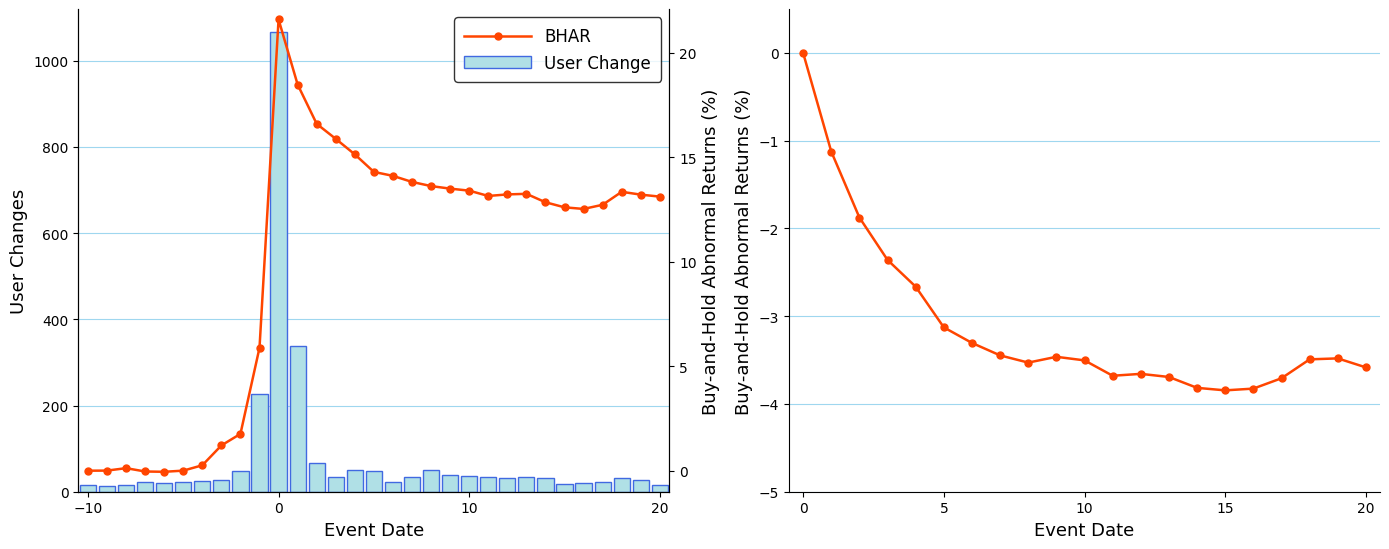

In [51]:
# ------------------------------------------------------------
# 6. PLOT FIGURE 6
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax1 = axes[0]
ax2 = axes[1]

# ----- Left panel: bars + BHAR line on twin axis
bars = ax1.bar(
    mean_userchg["rel_day"],
    mean_userchg["mean_userchg"],
    width=0.85,
    color="powderblue",
    edgecolor="royalblue",
    linewidth=1.0,
    label="User Change",
    zorder=1
)

ax1.set_xlabel("Event Date", fontsize=13)
ax1.set_ylabel("User Changes", fontsize=13)
ax1.set_xlim(window_start - 0.5, window_end + 0.5)
ax1.set_xticks([-10, 0, 10, 20])
ax1.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax1.set_axisbelow(True)

ax1b = ax1.twinx()
line1, = ax1b.plot(
    left_bhar["rel_day"],
    100 * left_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    label="BHAR",
    zorder=3
)

ax1b.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax1b.set_ylim(min(-1, 100 * left_bhar["mean_bhar"].min() - 0.5),
              max(22, 100 * left_bhar["mean_bhar"].max() + 0.5))

# legend matching order in paper
handles = [line1, bars]
labels = ["BHAR", "User Change"]
ax1.legend(
    handles, labels,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=12,
    handlelength=4,
    borderpad=0.6
)

# ----- Right panel: postevent BHAR only
ax2.plot(
    right_bhar["rel_day"],
    100 * right_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    zorder=3
)

ax2.set_xlabel("Event Date", fontsize=13)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax2.set_xlim(-0.5, window_end + 0.5)
ax2.set_xticks([0, 5, 10, 15, 20])
ax2.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax2.set_axisbelow(True)

# set right-panel y-range close to published figure
ax2.set_ylim(-5, 0.5)

# cosmetic cleanup
for ax in [ax1, ax2, ax1b]:
    ax.spines["top"].set_visible(False)

ax2.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("../../../figures/figure_6_replication.pdf", bbox_inches="tight")
plt.show()

And for the attention sample, even if I excpect the figure to not as neat as the one above; which replicates very well Barber et al. (2022).

In [52]:
# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------
df = attention.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

req = ["date", "ticker", "rh_herd", "userchg", "ret", "mkt_ret"]
df = df.dropna(subset=req).copy()

# trading-day index within ticker
df["td_idx"] = df.groupby("ticker").cumcount()

# event list
events = df.loc[df["rh_herd"] == 1, ["ticker", "date"]].copy()
events = events.rename(columns={"date": "event_date"})
events["event_id"] = np.arange(len(events))

print(f"Number of herding events: {len(events):,}")

# attach td_idx of each event day
event_base = events.merge(
    df[["ticker", "date", "td_idx"]],
    left_on=["ticker", "event_date"],
    right_on=["ticker", "date"],
    how="left"
).drop(columns=["date"])

# ------------------------------------------------------------
# 2. BUILD EVENT-TIME PANEL
# ------------------------------------------------------------
# Figure caption says 10 days before to 21 days after.
# The paper plot appears to show points up to 20.
# To match the visible figure, use -10 to +20.
# If you want the literal caption, set window_end = 21.
# ------------------------------------------------------------
window_start = -10
window_end = 20

rel_days = pd.DataFrame({"rel_day": np.arange(window_start, window_end + 1)})
event_panel = event_base.merge(rel_days, how="cross")
event_panel["target_td_idx"] = event_panel["td_idx"] + event_panel["rel_day"]

# pull event-time observations
cols_to_pull = ["ticker", "td_idx", "date", "userchg", "ret", "mkt_ret"]
event_panel = event_panel.merge(
    df[cols_to_pull],
    left_on=["ticker", "target_td_idx"],
    right_on=["ticker", "td_idx"],
    how="left",
    suffixes=("", "_obs")
)

event_panel = event_panel.rename(columns={"date": "obs_date"})
event_panel = event_panel.dropna(subset=["userchg", "ret", "mkt_ret"]).copy()
event_panel = event_panel.sort_values(["event_id", "rel_day"]).reset_index(drop=True)

# ------------------------------------------------------------
# 3. MEAN USER CHANGE BY EVENT TIME
# ------------------------------------------------------------
# Gray bars in the left panel
# ------------------------------------------------------------
mean_userchg = (
    event_panel.groupby("rel_day", as_index=False)["userchg"]
    .mean()
    .rename(columns={"userchg": "mean_userchg"})
)

# ------------------------------------------------------------
# 4. MEAN BHAR BY EVENT TIME
# ------------------------------------------------------------
# LEFT PANEL:
# For each event day tau in [-10, ..., 20], compute BHAR from -10 to tau
#
# RIGHT PANEL:
# For each event day tau in [0, ..., 20], compute postevent BHAR starting at day 0
#
# This matches the figure caption language.
# If you wanted to mimic Table VIII exactly, postevent BHAR would start at day 1.
# But Figure 6 explicitly says "starting from day 0."
# ------------------------------------------------------------

# ---- Left-panel BHAR: cumulate from -10 to tau
left_bhar_rows = []

for tau in range(window_start, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(window_start, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    left_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

left_bhar = pd.DataFrame(left_bhar_rows)

# ---- Right-panel BHAR: postevent path starting at day 0 = 0
# day 0 is normalized to 0
right_bhar_rows = [{"rel_day": 0, "mean_bhar": 0.0}]

for tau in range(1, window_end + 1):
    tmp = event_panel.loc[event_panel["rel_day"].between(1, tau)].copy()
    tmp = tmp.sort_values(["event_id", "rel_day"])

    grp = tmp.groupby(["event_id", "event_date"], as_index=False).agg(
        stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
        mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
    )
    grp["BHAR"] = grp["stock_leg"] - grp["mkt_leg"]

    right_bhar_rows.append({
        "rel_day": tau,
        "mean_bhar": grp["BHAR"].mean()
    })

right_bhar = pd.DataFrame(right_bhar_rows)

Number of herding events: 2,001


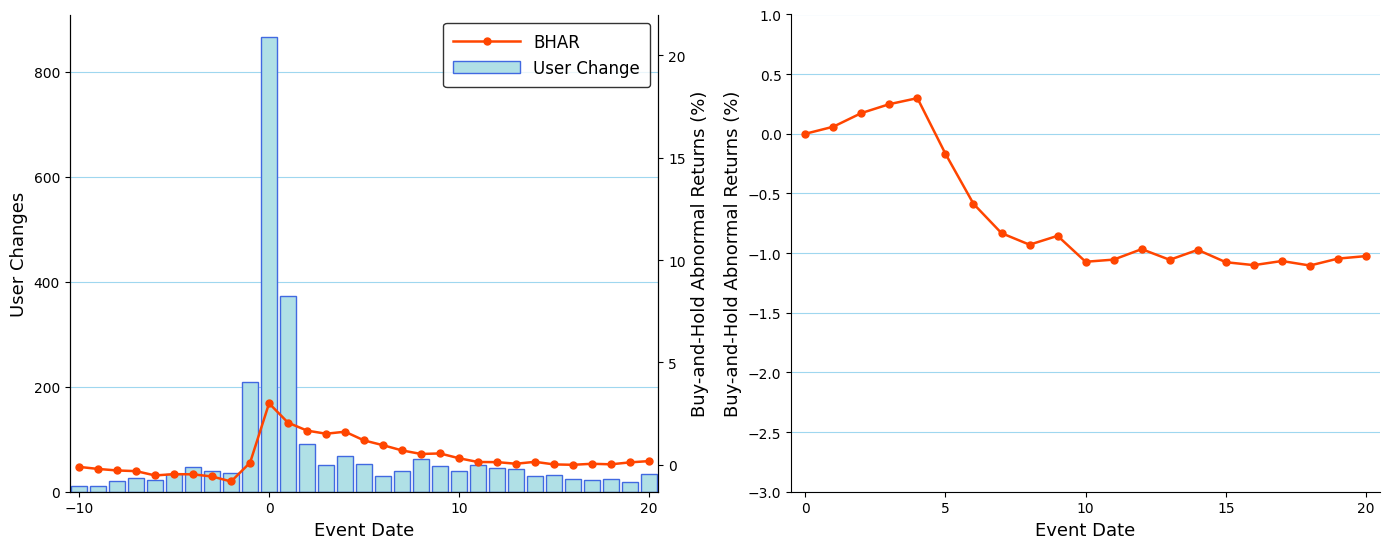

In [53]:
# ------------------------------------------------------------
# 6. PLOT FIGURE 6
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ax1 = axes[0]
ax2 = axes[1]

# ----- Left panel: bars + BHAR line on twin axis
bars = ax1.bar(
    mean_userchg["rel_day"],
    mean_userchg["mean_userchg"],
    width=0.85,
    color="powderblue",
    edgecolor="royalblue",
    linewidth=1.0,
    label="User Change",
    zorder=1
)

ax1.set_xlabel("Event Date", fontsize=13)
ax1.set_ylabel("User Changes", fontsize=13)
ax1.set_xlim(window_start - 0.5, window_end + 0.5)
ax1.set_xticks([-10, 0, 10, 20])
ax1.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax1.set_axisbelow(True)

ax1b = ax1.twinx()
line1, = ax1b.plot(
    left_bhar["rel_day"],
    100 * left_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    label="BHAR",
    zorder=3
)

ax1b.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax1b.set_ylim(min(-1, 100 * left_bhar["mean_bhar"].min() - 0.5),
              max(22, 100 * left_bhar["mean_bhar"].max() + 0.5))

# legend matching order in paper
handles = [line1, bars]
labels = ["BHAR", "User Change"]
ax1.legend(
    handles, labels,
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="black",
    fontsize=12,
    handlelength=4,
    borderpad=0.6
)

# ----- Right panel: postevent BHAR only
ax2.plot(
    right_bhar["rel_day"],
    100 * right_bhar["mean_bhar"],
    color="orangered",
    marker="o",
    markersize=5,
    linewidth=1.8,
    zorder=3
)

ax2.set_xlabel("Event Date", fontsize=13)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (%)", fontsize=13)
ax2.set_xlim(-0.5, window_end + 0.5)
ax2.set_xticks([0, 5, 10, 15, 20])
ax2.grid(axis="y", alpha=0.8, zorder=0, color="skyblue")
ax2.set_axisbelow(True)

# set right-panel y-range close to published figure
ax2.set_ylim(-3, 1)

# cosmetic cleanup
for ax in [ax1, ax2, ax1b]:
    ax.spines["top"].set_visible(False)

ax2.spines["right"].set_visible(False)

fig.tight_layout()
plt.savefig("../../../figures/figure_6_attention_replication.pdf", bbox_inches="tight")
plt.show()

## 3. Reproduction of Figure 7

Reproducing figure 7 requires a little more work because we have to define herding events for a range od different $\textit{userratio}_{i, t}$.

In [94]:
# ============================================================
# LOAD DATA
# ============================================================
base2 = pd.read_csv("../../../data/processed/baseline_trading_sample.csv")

base2["date"] = pd.to_datetime(base2["date"])
crsp_idx["date"] = pd.to_datetime(crsp_idx["date"])

base2 = pd.merge(base2, crsp_idx[["date", "mkt_ret"]], on="date", how="left")
base2["aret"] = base2["ret"] - base2["mkt_ret"]

base2 = base2.sort_values(["ticker", "date"]).reset_index(drop=True)
base2["users_close_lag1"] = base2.groupby("ticker")["users_close"].shift(1)
base2["userratio"] = base2["users_close"] / base2["users_close_lag1"]
base2["userratio"] = base2["userratio"].replace([np.inf, -np.inf], np.nan)
base2["td_idx"] = base2.groupby("ticker").cumcount()

base2 = base2.dropna(
    subset=["ticker", "date", "ret", "mkt_ret", "userratio", "users_close_lag1", "td_idx"]
).copy()


# ============================================================
# FUNCTION: EVENT COUNT + 20-DAY POSTEVENT BHAR + 90% CI
# ============================================================
def compute_fig7_stats_for_cutoff(df, cutoff, z=1.645):
    events = df.loc[
        (df["userratio"] >= cutoff) &
        (df["users_close_lag1"] >= 100),
        ["ticker", "date", "td_idx"]
    ].copy()

    n_events = len(events)
    if n_events == 0:
        return {
            "n_events": 0,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    events = events.rename(columns={"date": "event_date", "td_idx": "event_td_idx"})
    events["event_id"] = np.arange(n_events)

    # days +1 to +20
    rel_days = pd.DataFrame({"rel_day": np.arange(1, 21)})
    panel = events.merge(rel_days, how="cross")
    panel["target_td_idx"] = panel["event_td_idx"] + panel["rel_day"]

    panel = panel.merge(
        df[["ticker", "td_idx", "ret", "mkt_ret"]],
        left_on=["ticker", "target_td_idx"],
        right_on=["ticker", "td_idx"],
        how="left"
    )

    panel = panel.dropna(subset=["ret", "mkt_ret"]).copy()

    counts = panel.groupby("event_id")["rel_day"].nunique()
    valid_ids = counts[counts == 20].index

    if len(valid_ids) == 0:
        return {
            "n_events": n_events,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    panel = panel[panel["event_id"].isin(valid_ids)].copy()

    event_bhar = (
        panel.sort_values(["event_id", "rel_day"])
             .groupby("event_id", as_index=False)
             .agg(
                 stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
                 mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
             )
    )
    event_bhar["bhar_20d"] = event_bhar["stock_leg"] - event_bhar["mkt_leg"]

    x = event_bhar["bhar_20d"]
    n_complete = len(x)
    mean_bhar = x.mean()

    # standard error of the mean
    se_bhar = x.std(ddof=1) / np.sqrt(n_complete) if n_complete > 1 else np.nan

    ci_low = mean_bhar - z * se_bhar if pd.notna(se_bhar) else np.nan
    ci_high = mean_bhar + z * se_bhar if pd.notna(se_bhar) else np.nan

    return {
        "n_events": n_events,
        "bhar_20d": mean_bhar,
        "se_bhar_20d": se_bhar,
        "ci90_low": ci_low,
        "ci90_high": ci_high,
        "n_complete": n_complete
    }


# ============================================================
# SWEEP OVER CUTOFFS
# ============================================================
cutoffs = np.round(np.arange(1.1, 8.5 + 0.001, 0.1), 1)

results = []
for c in cutoffs:
    out = compute_fig7_stats_for_cutoff(base2, c)
    results.append({
        "cutoff": c,
        **out
    })

fig7_df = pd.DataFrame(results)

fig7_df.head()

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_54930/3266820942.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  base2 = pd.read_csv("../../../data/processed/baseline_trading_sample.csv")


,cutoff,n_events,bhar_20d,se_bhar_20d,ci90_low,ci90_high,n_complete
0,1.1,20852,-0.003468,0.003011,-0.008420,0.001485,15342
1,1.2,9070,-0.019912,0.004765,-0.027749,-0.012074,6708
2,1.3,5574,-0.030048,0.006239,-0.040311,-0.019785,4122
3,1.4,3978,-0.036131,0.006576,-0.046948,-0.025314,2932
4,1.5,3018,-0.037821,0.007647,-0.050401,-0.025241,2238


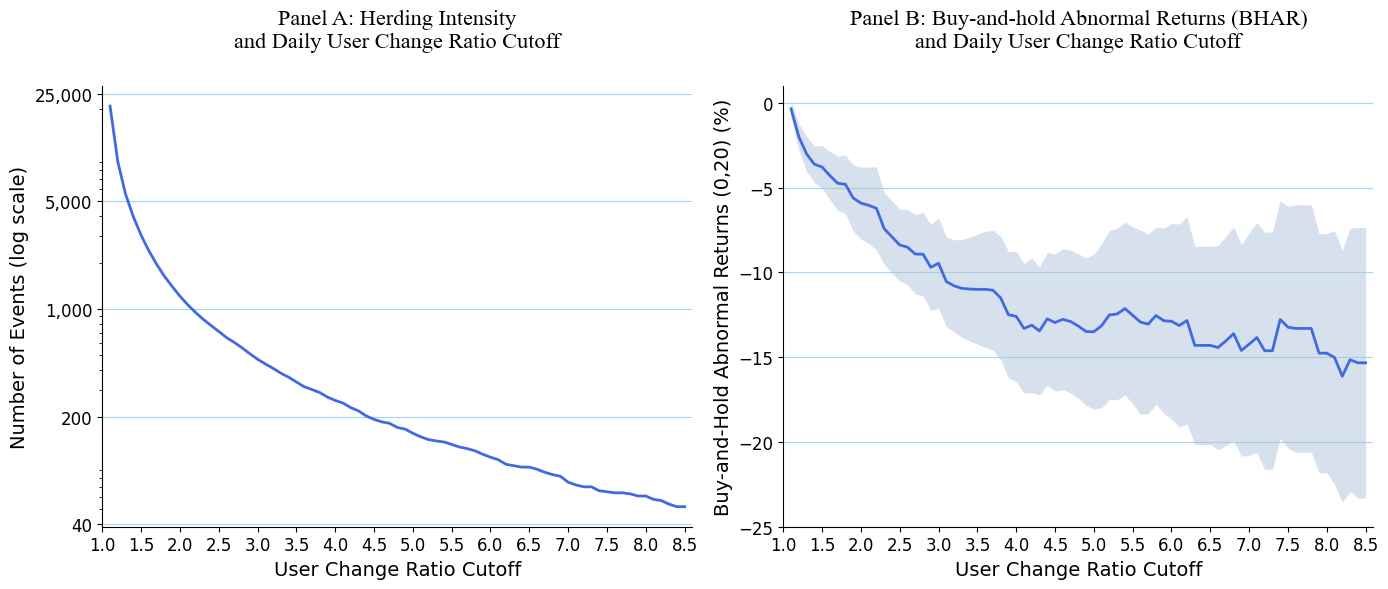

In [95]:
plot_b = fig7_df.dropna(subset=["bhar_20d"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- Panel A ----------------
ax1 = axes[0]
ax1.plot(
    fig7_df["cutoff"],
    fig7_df["n_events"],
    color="royalblue",
    linewidth=2
)
ax1.set_title(
    "Panel A: Herding Intensity\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax1.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax1.set_ylabel("Number of Events (log scale)", fontsize=14)
ax1.set_yscale("log")
ax1.set_xlim(1.0, 8.6)
ax1.set_xticks(np.arange(1.0, 8.6, 0.5))
ax1.set_yticks([40, 200, 1000, 5000, 25000])
ax1.set_yticklabels(["40", "200", "1,000", "5,000", "25,000"])
ax1.grid(axis="y", alpha=0.8, color="skyblue")
ax1.set_axisbelow(True)

# ---------------- Panel B ----------------
ax2 = axes[1]
ax2.plot(
    plot_b["cutoff"],
    100 * plot_b["bhar_20d"],
    color="royalblue",
    linewidth=2
)
# 90% confidence band
ax2.fill_between(
    plot_b["cutoff"],
    100 * plot_b["ci90_low"],
    100 * plot_b["ci90_high"],
    color="lightsteelblue",
    alpha=0.5,
    linewidth=0
)
ax2.set_title(
    "Panel B: Buy-and-hold Abnormal Returns (BHAR)\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax2.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (0,20) (%)", fontsize=14)
ax2.set_xlim(1.0, 8.6)
ax2.set_xticks(np.arange(1.0, 8.6, 0.5))
ax2.set_ylim(-25, 1)
ax2.set_yticks([0, -5, -10, -15, -20, -25])
ax2.grid(axis="y", alpha=0.8, color="skyblue")
ax2.set_axisbelow(True)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig("../../../figures/figure_7_replication_baseline.pdf", bbox_inches="tight")
plt.show()

I again reproduce the same thing but for the attention sample.

In [96]:
# ============================================================
# LOAD DATA
# ============================================================
base2 = pd.read_csv("../../../data/processed/attention_sample.csv")

base2["date"] = pd.to_datetime(base2["date"])
crsp_idx["date"] = pd.to_datetime(crsp_idx["date"])

base2 = pd.merge(base2, crsp_idx[["date", "mkt_ret"]], on="date", how="left")
base2["aret"] = base2["ret"] - base2["mkt_ret"]

base2 = base2.sort_values(["ticker", "date"]).reset_index(drop=True)
base2["users_close_lag1"] = base2.groupby("ticker")["users_close"].shift(1)
base2["userratio"] = base2["users_close"] / base2["users_close_lag1"]
base2["userratio"] = base2["userratio"].replace([np.inf, -np.inf], np.nan)
base2["td_idx"] = base2.groupby("ticker").cumcount()

base2 = base2.dropna(
    subset=["ticker", "date", "ret", "mkt_ret", "userratio", "users_close_lag1", "td_idx"]
).copy()


# ============================================================
# FUNCTION: EVENT COUNT + 20-DAY POSTEVENT BHAR + 90% CI
# ============================================================
def compute_fig7_stats_for_cutoff(df, cutoff, z=1.645):
    events = df.loc[
        (df["userratio"] >= cutoff) &
        (df["users_close_lag1"] >= 100),
        ["ticker", "date", "td_idx"]
    ].copy()

    n_events = len(events)
    if n_events == 0:
        return {
            "n_events": 0,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    events = events.rename(columns={"date": "event_date", "td_idx": "event_td_idx"})
    events["event_id"] = np.arange(n_events)

    # days +1 to +20
    rel_days = pd.DataFrame({"rel_day": np.arange(1, 21)})
    panel = events.merge(rel_days, how="cross")
    panel["target_td_idx"] = panel["event_td_idx"] + panel["rel_day"]

    panel = panel.merge(
        df[["ticker", "td_idx", "ret", "mkt_ret"]],
        left_on=["ticker", "target_td_idx"],
        right_on=["ticker", "td_idx"],
        how="left"
    )

    panel = panel.dropna(subset=["ret", "mkt_ret"]).copy()

    counts = panel.groupby("event_id")["rel_day"].nunique()
    valid_ids = counts[counts == 20].index

    if len(valid_ids) == 0:
        return {
            "n_events": n_events,
            "bhar_20d": np.nan,
            "se_bhar_20d": np.nan,
            "ci90_low": np.nan,
            "ci90_high": np.nan,
            "n_complete": 0
        }

    panel = panel[panel["event_id"].isin(valid_ids)].copy()

    event_bhar = (
        panel.sort_values(["event_id", "rel_day"])
             .groupby("event_id", as_index=False)
             .agg(
                 stock_leg=("ret", lambda x: np.prod(1 + x) - 1),
                 mkt_leg=("mkt_ret", lambda x: np.prod(1 + x) - 1)
             )
    )
    event_bhar["bhar_20d"] = event_bhar["stock_leg"] - event_bhar["mkt_leg"]

    x = event_bhar["bhar_20d"]
    n_complete = len(x)
    mean_bhar = x.mean()

    # standard error of the mean
    se_bhar = x.std(ddof=1) / np.sqrt(n_complete) if n_complete > 1 else np.nan

    ci_low = mean_bhar - z * se_bhar if pd.notna(se_bhar) else np.nan
    ci_high = mean_bhar + z * se_bhar if pd.notna(se_bhar) else np.nan

    return {
        "n_events": n_events,
        "bhar_20d": mean_bhar,
        "se_bhar_20d": se_bhar,
        "ci90_low": ci_low,
        "ci90_high": ci_high,
        "n_complete": n_complete
    }


# ============================================================
# SWEEP OVER CUTOFFS
# ============================================================
cutoffs = np.round(np.arange(1.1, 4.0 + 0.001, 0.1), 1)

results = []
for c in cutoffs:
    out = compute_fig7_stats_for_cutoff(base2, c)
    results.append({
        "cutoff": c,
        **out
    })

fig7_df = pd.DataFrame(results)

fig7_df.head()

/var/folders/7v/_v_y1jpx0rl056gg5rkjsw4r0000gn/T/ipykernel_54930/3791843490.py:4: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  base2 = pd.read_csv("../../../data/processed/attention_sample.csv")


,cutoff,n_events,bhar_20d,se_bhar_20d,ci90_low,ci90_high,n_complete
0,1.1,5537,0.007385,0.004025,0.000765,0.014006,4150
1,1.2,2260,0.001630,0.006939,-0.009785,0.013045,1675
2,1.3,1360,-0.004759,0.007715,-0.017451,0.007932,1007
3,1.4,951,-0.008743,0.009408,-0.024219,0.006734,706
4,1.5,679,-0.003981,0.010421,-0.021125,0.013162,513


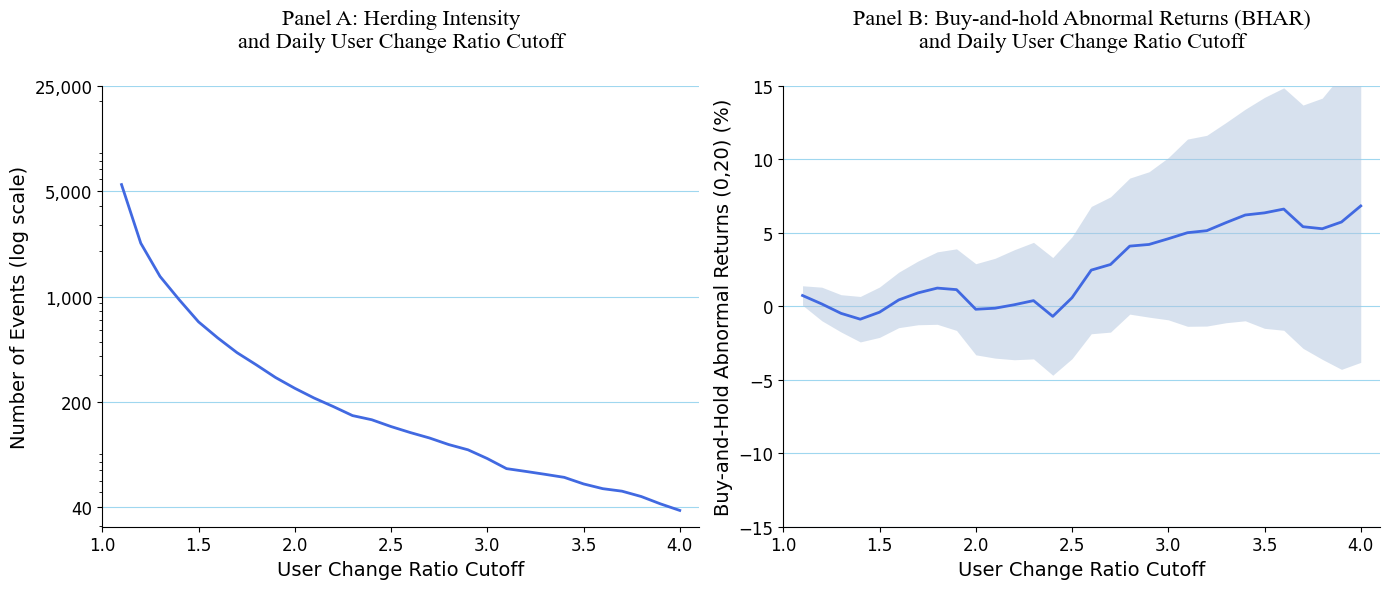

In [97]:
plot_b = fig7_df.dropna(subset=["bhar_20d"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------- Panel A ----------------
ax1 = axes[0]
ax1.plot(
    fig7_df["cutoff"],
    fig7_df["n_events"],
    color="royalblue",
    linewidth=2
)
ax1.set_title(
    "Panel A: Herding Intensity\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax1.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax1.set_ylabel("Number of Events (log scale)", fontsize=14)
ax1.set_yscale("log")
ax1.set_xlim(1.0, 4.1)
ax1.set_xticks(np.arange(1.0, 4.3, 0.5))
ax1.set_yticks([40, 200, 1000, 5000, 25000])
ax1.set_yticklabels(["40", "200", "1,000", "5,000", "25,000"])
ax1.grid(axis="y", alpha=0.8, color="skyblue")
ax1.set_axisbelow(True)

# ---------------- Panel B ----------------
ax2 = axes[1]
ax2.plot(
    plot_b["cutoff"],
    100 * plot_b["bhar_20d"],
    color="royalblue",
    linewidth=2
)
# 90% confidence band
ax2.fill_between(
    plot_b["cutoff"],
    100 * plot_b["ci90_low"],
    100 * plot_b["ci90_high"],
    color="lightsteelblue",
    alpha=0.5,
    linewidth=0
)
ax2.set_title(
    "Panel B: Buy-and-hold Abnormal Returns (BHAR)\nand Daily User Change Ratio Cutoff",
    fontsize=16,
    pad=28,
    family="Times New Roman"
)
ax2.set_xlabel("User Change Ratio Cutoff", fontsize=14)
ax2.set_ylabel("Buy-and-Hold Abnormal Returns (0,20) (%)", fontsize=14)
ax2.set_xlim(1.0, 4.1)
ax2.set_xticks(np.arange(1.0, 4.3, 0.5))
ax2.set_ylim(-15, 15)
ax2.set_yticks([-15, -10, -5, 0, 5, 10, 15])
ax2.grid(axis="y", alpha=0.8, color="skyblue")
ax2.set_axisbelow(True)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig("../../../figures/figure_7_replication_attention.pdf", bbox_inches="tight")
plt.show()

Considering earlier results, it is not surprising that the attention sample does not reproduce the findings of Barber et al. (2022).